In [1]:
!pip install onvif-zeep


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 KB 703.0 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.2/101.2 KB 1.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 KB 1.1 MB/s eta 0:00:0000:01
  Created wheel for onvif-zeep: filename=onvif_zeep-0.2.12-py3-none-any.whl size=192774 sha256=3b8bf5258795189c8dc48cf15b47550989b9950e1bbbf57cfb7eb4315ce9c788
  Stored in directory: /home/baseer/.cache/pip/wheels/97/4a/8c/06372489b655e734dba9f0b88cf51f77a5c5636e55043955b0
Successfully built onvif-zeep


In [ ]:
from onvif import ONVIFCamera

# Replace with your camera's IP, port, username, and password
mycam = ONVIFCamera('192.168.100.25', 80, 'onvif_user1', 'Q12345678q')

# Create media service
media_service = mycam.create_media_service()

# Get the video source configuration
video_source_config = media_service.GetVideoSourceConfigurations()[0]

# Get the imaging service
imaging_service = mycam.create_imaging_service()

# Get current imaging settings
video_source_token = video_source_config.SourceToken
imaging_settings = imaging_service.GetImagingSettings({'VideoSourceToken': video_source_token})

# Change brightness value
imaging_settings.Brightness = 60  # Adjust the brightness value

# Apply the new settings
imaging_service.SetImagingSettings({'VideoSourceToken': video_source_token}, imaging_settings)

print("Brightness adjusted successfully")


In [7]:
!pip install hikvisionapi

Defaulting to user installation because normal site-packages is not writeable


In [8]:
from hikvisionapi import Client

cam = Client('http://192.168.0.124', 'admin', 'Q12345678q')


# Dict response (default)
response = cam.System.deviceInfo(method='get')

In [9]:
response

{'DeviceInfo': {'@version': '2.0',
  '@xmlns': 'http://www.isapi.org/ver20/XMLSchema',
  'deviceName': 'Network Video Recorder',
  'deviceID': '48414b36-3634-3934-3031-3c1bf82223d8',
  'model': 'DS-9664NI-M8',
  'serialNumber': 'DS-9664NI-M81620231031CCRRAK6649401WCVU',
  'macAddress': '3c:1b:f8:22:23:d8',
  'firmwareVersion': 'V4.63.020',
  'firmwareReleasedDate': 'build 230808',
  'encoderVersion': 'V5.0',
  'encoderReleasedDate': 'build 230718',
  'deviceType': 'NVR',
  'telecontrolID': '255',
  'hardwareVersion': 'B-R-K21B1-00',
  'decordChannelNums': '16',
  'VGANums': '2',
  'USBNums': '4',
  'auxoutNums': '0',
  'regionVersion': 'basic',
  'deviceMaintenanceInfoQRCode': None}}

In [14]:
# Get and save picture from camera            
response = cam.Streaming.channels[401].picture(method='get', type='opaque_data')
with open('screen.jpg', 'wb') as f:
    for chunk in response.iter_content(chunk_size=1024):
        if chunk:
            f.write(chunk)

In [12]:
import requests
from requests.auth import HTTPBasicAuth, HTTPDigestAuth

brightness_url = 'http://192.168.0.124/ISAPI/ContentMgmt/ImageProxy/channels/4'

xml_data = '''
<?xml version="1.0" encoding="UTF-8"?><ImageChannel xmlns="http://www.isapi.org/ver20/XMLSchema" version="2.0">
<id>4</id>
<inputPort>4</inputPort>
<Color>
<brightnessLevel>90</brightnessLevel>
<contrastLevel>50</contrastLevel>
<saturationLevel>50</saturationLevel>
</Color>
<enableImageLossDetection>false</enableImageLossDetection>
</ImageChannel>
'''


In [16]:
DEFAULT_HEADERS = {
    'Content-Type': "application/xml; charset='UTF-8'",
    'Accept': "*/*"
}

In [17]:
response = requests.put(brightness_url, data=xml_data, auth=HTTPDigestAuth('admin', 'Q12345678q'), headers=DEFAULT_HEADERS)

In [18]:
response

<Response [200]>

In [2]:
import cv2
import numpy as np
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from requests.auth import HTTPDigestAuth

DEFAULT_HEADERS = {
    'Content-Type': "application/xml; charset='UTF-8'",
    'Accept': "*/*"
}

camera_ip = '192.168.0.124'
username = 'admin'
password = 'Q12345678q'



def fetch_image_from_hikvision(snapshot_url):
    response = requests.get(snapshot_url, auth=HTTPDigestAuth('admin', 'Q12345678q'), headers=DEFAULT_HEADERS)
    
    if response.status_code == 200:
        # Convert the response content (image bytes) to an image
        image = Image.open(BytesIO(response.content))
        return np.array(image)
    else:
        print(f"Failed to fetch image, status code: {response.status_code}")
        return None
    
# Function to check if the image is too dark
def is_dark(image, brightness_threshold=50):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Calculate the average brightness
    avg_brightness = np.mean(gray_image)
    
    # Check if brightness is below the threshold
    if avg_brightness < brightness_threshold:
        return True
    else:
        return False

In [3]:
for i in range(65):
    # try:
        camera_id = int(f'{i}01')
        # print(camera_id)
        snapshot_url = f'http://{camera_ip}/ISAPI/Streaming/channels/{camera_id}/picture'
        image = fetch_image_from_hikvision(snapshot_url)
        if image is not None:
            cv2.imwrite(f'./camera_snapshots/{camera_id}.png', image)
            #plt.imshow(image)
            if is_dark(image):
                print(f'{camera_id} is True')
    # except:
    #     continue

Failed to fetch image, status code: 403
Failed to fetch image, status code: 403
Failed to fetch image, status code: 403


In [85]:
image.shape

(576, 704, 3)

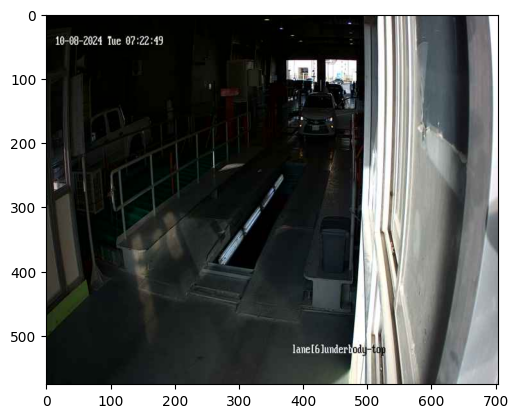

In [45]:
camera_id = int(f'2801')
        # print(camera_id)
snapshot_url = f'http://{camera_ip}/ISAPI/Streaming/channels/{camera_id}/picture'
image = fetch_image_from_hikvision(snapshot_url)
if image is not None:
    plt.imshow(image)
    if is_dark(image):
        print(f'{camera_id} is True')

False